In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_excel('chatgpt_style_reviews_dataset (1).xlsx')

In [3]:
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [4]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')

In [5]:
df.dtypes

,0
date,object
title,object
review,object
rating,int64
username,object
helpful_votes,int64
review_length,int64
platform,object
language,object
location,object


In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

text_cols = ["title", "review", "username", "version"]
df[text_cols] = df[text_cols].astype("string")

int_cols = ["rating", "helpful_votes", "review_length"]
df[int_cols] = df[int_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")

cat_cols = ["platform", "language", "location"]
df[cat_cols] = df[cat_cols].astype("category")

df["verified_purchase"] = df["verified_purchase"].astype("bool")


/tmp/ipython-input-2912839496.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


In [7]:
df["date_only"] = df["date"].dt.date

df["date_only"].value_counts().sort_index(ascending=False)


,count
date_only,
2025-05-09,2
2025-05-08,2
2025-05-05,1
2025-05-04,1
2025-05-03,2
...,...
2024-01-05,2
2024-01-04,2
2024-01-03,1


In [8]:
# See rows where date parsing failed
df[df["date"].isna()]


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,date_only
0,NaT,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,True,NaT
1,NaT,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,True,NaT
2,NaT,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,True,NaT
3,NaT,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,True,NaT
4,NaT,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,True,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,NaT,Review title 494,"Terrible experience, needs major improvements.",1,user494,50,5,Google Play,zh,India,4.2.1,True,NaT
494,NaT,Review title 495,Very reliable and worth using regularly.,4,user495,26,6,App Store,ja,Qatar,5.0.3,True,NaT
496,NaT,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,True,NaT
497,NaT,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,True,NaT


In [9]:
df

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,date_only
0,NaT,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,True,NaT
1,NaT,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,True,NaT
2,NaT,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,True,NaT
3,NaT,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,True,NaT
4,NaT,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,True,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-07-05,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,True,2024-07-05
496,NaT,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,True,NaT
497,NaT,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,True,NaT
498,NaT,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,True,NaT


In [10]:
df.drop(columns=['title','username'],inplace=True)

In [11]:
df

,date,review,rating,helpful_votes,review_length,platform,language,location,version,verified_purchase,date_only
0,NaT,"Not satisfied, many bugs and issues.",1,80,6,Amazon,zh,Kenya,2.1.4,True,NaT
1,NaT,Amazing quality and user-friendly interface.,5,180,5,Flipkart,zh,France,1.2.3,True,NaT
2,NaT,"Terrible experience, needs major improvements.",2,154,5,Flipkart,pt,USA,1.2.3,True,NaT
3,NaT,Poor performance and not user-friendly.,1,96,5,Amazon,es,Qatar,2.1.4,True,NaT
4,NaT,"Not satisfied, many bugs and issues.",2,139,6,Website,ar,Kenya,2.1.4,True,NaT
...,...,...,...,...,...,...,...,...,...,...,...
495,2024-07-05,"Waste of time, does not meet expectations.",2,81,7,Flipkart,ja,Qatar,1.2.3,True,2024-07-05
496,NaT,"Great experience, smooth performance and usefu...",5,48,7,Google Play,fr,Nepal,2.1.4,True,NaT
497,NaT,"Terrible experience, needs major improvements.",2,16,5,Google Play,de,Poland,2.1.4,True,NaT
498,NaT,"Highly satisfied, the app works exactly as exp...",4,68,8,Google Play,zh,Nepal,1.2.3,True,NaT


In [12]:
import re

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
df['review'] = df['review'].fillna('')

In [14]:
def map_rating(r):
    if r >= 4:
        return 2      # Positive
    elif r == 3:
        return 1      # Neutral
    else:
        return 0      # Negative

df['sentiment'] = df['rating'].apply(map_rating)

In [15]:
# Load spacy model
nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))


def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove special characters & numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc]

    return " ".join(lemmas)


In [16]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_review'] = df['review'].astype(str).apply(clean_text)


In [18]:
#EDA

In [19]:
!pip install wordcloud seaborn nltk -q


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
from collections import Counter
import pandas as pd
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)


In [21]:
print("📊 Current df info:")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nRating sample:\n", df['rating'].value_counts().sort_index())
print("\nPlatform sample:", df['platform'].value_counts())
print("Verified unique:", df['verified_purchase'].unique())
print("✅ Data verified!")


📊 Current df info:
Shape: (500, 13)
Columns: ['date', 'review', 'rating', 'helpful_votes', 'review_length', 'platform', 'language', 'location', 'version', 'verified_purchase', 'date_only', 'sentiment', 'clean_review']

Rating sample:
 rating
1     89
2    106
3    105
4    110
5     90
Name: count, dtype: Int64

Platform sample: platform
Flipkart       113
Website        103
Google Play    102
App Store       92
Amazon          90
Name: count, dtype: int64
Verified unique: [ True]
✅ Data verified!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


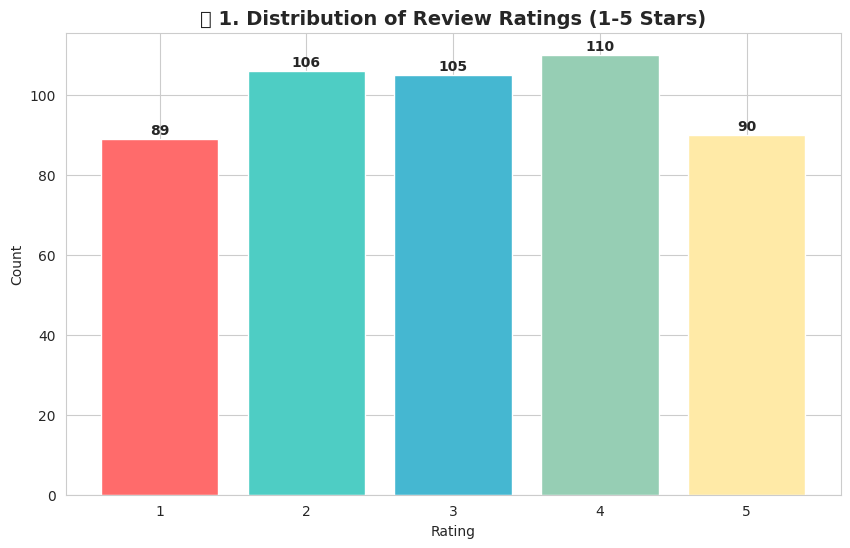

Insight: Mostly happy sentiment


In [22]:
#1 EDA
plt.figure(figsize=(10, 6))
rating_counts = df['rating'].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('📊 1. Distribution of Review Ratings (1-5 Stars)', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(range(1,6))
for i, v in enumerate(rating_counts.values):
    plt.text(i+1, v+1, str(v), ha='center', fontweight='bold')
plt.show()
print(f"Insight: {'Mostly happy' if rating_counts[5] > rating_counts[1] else 'Polarized/mixed'} sentiment")



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128078 (\N{THUMBS DOWN SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


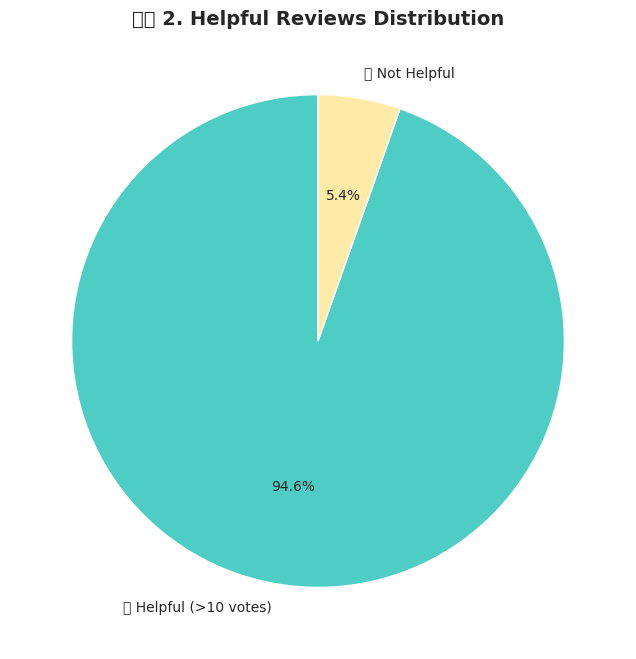

Insight: 473 (94.6%) reviews found valuable by community


In [23]:
#2
helpful = df[df['helpful_votes'] > 10].shape[0]
total = len(df)
plt.figure(figsize=(8, 8))
plt.pie([helpful, total-helpful], labels=['👍 Helpful (>10 votes)', '👎 Not Helpful'],
        autopct='%1.1f%%', colors=['#4ECDC4', '#FFEAA7'], startangle=90)
plt.title('👍👎 2. Helpful Reviews Distribution', fontsize=14, fontweight='bold')
plt.show()
print(f"Insight: {helpful} ({helpful/total*100:.1f}%) reviews found valuable by community")



/tmp/ipython-input-2706790317.py:21: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


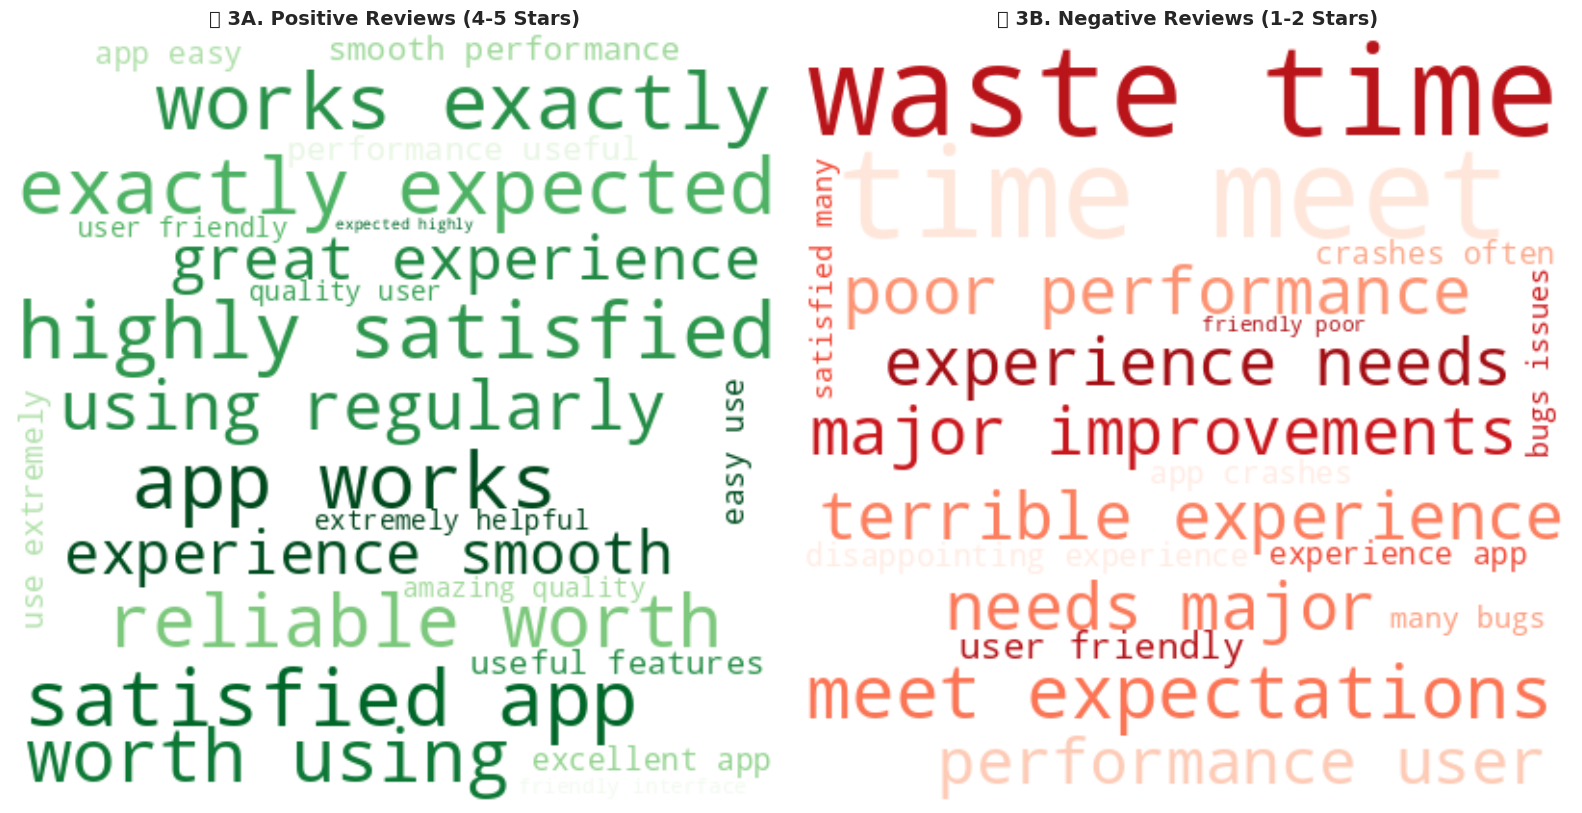

In [24]:
#3
def clean_words(text):
    if pd.isna(text): return ''
    words = re.findall(r'\b[a-zA-Z]{3,}\b', str(text).lower())
    return ' '.join([w for w in words if w not in stop_words])

pos_reviews = df[df['rating'] >= 4]['review'].apply(clean_words)
neg_reviews = df[df['rating'] <= 2]['review'].apply(clean_words)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
wc_pos = WordCloud(width=400, height=400, background_color='white', colormap='Greens').generate(' '.join(pos_reviews))
wc_neg = WordCloud(width=400, height=400, background_color='white', colormap='Reds').generate(' '.join(neg_reviews))

ax1.imshow(wc_pos, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('🧭 3A. Positive Reviews (4-5 Stars)', fontsize=14, fontweight='bold')

ax2.imshow(wc_neg, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('🧭 3B. Negative Reviews (1-2 Stars)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


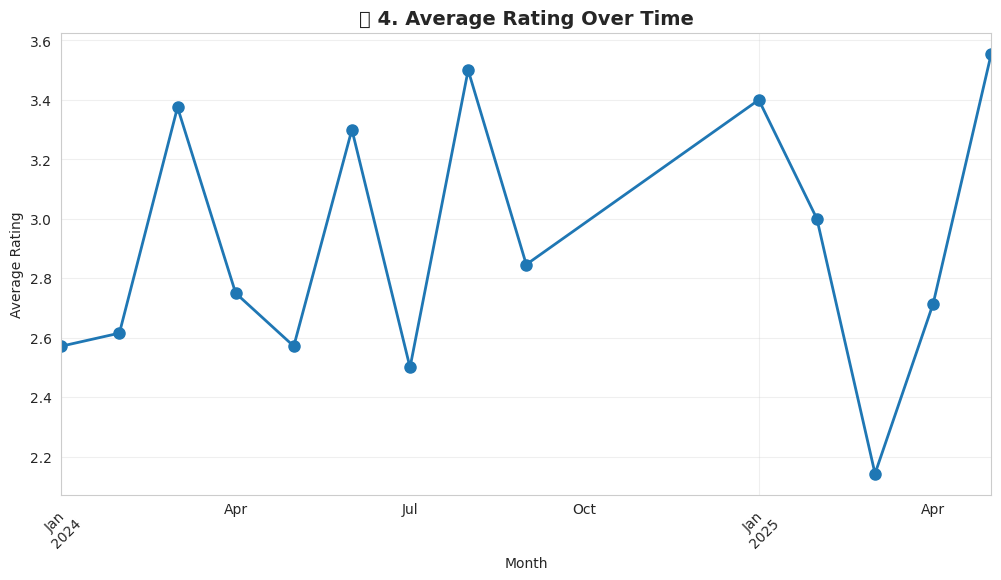

Insight: Upward trend


In [25]:
#4
df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')
monthly_rating = df.dropna(subset=['date_clean']).groupby(df['date_clean'].dt.to_period('M'))['rating'].mean()
plt.figure(figsize=(12, 6))
monthly_rating.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.title('📆 4. Average Rating Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
print("Insight:", "Upward trend" if monthly_rating.iloc[-1] > monthly_rating.iloc[0] else "Stable/declining")


/tmp/ipython-input-4244789403.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  location_ratings = df.groupby('location')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
/tmp/ipython-input-4244789403.py:14: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


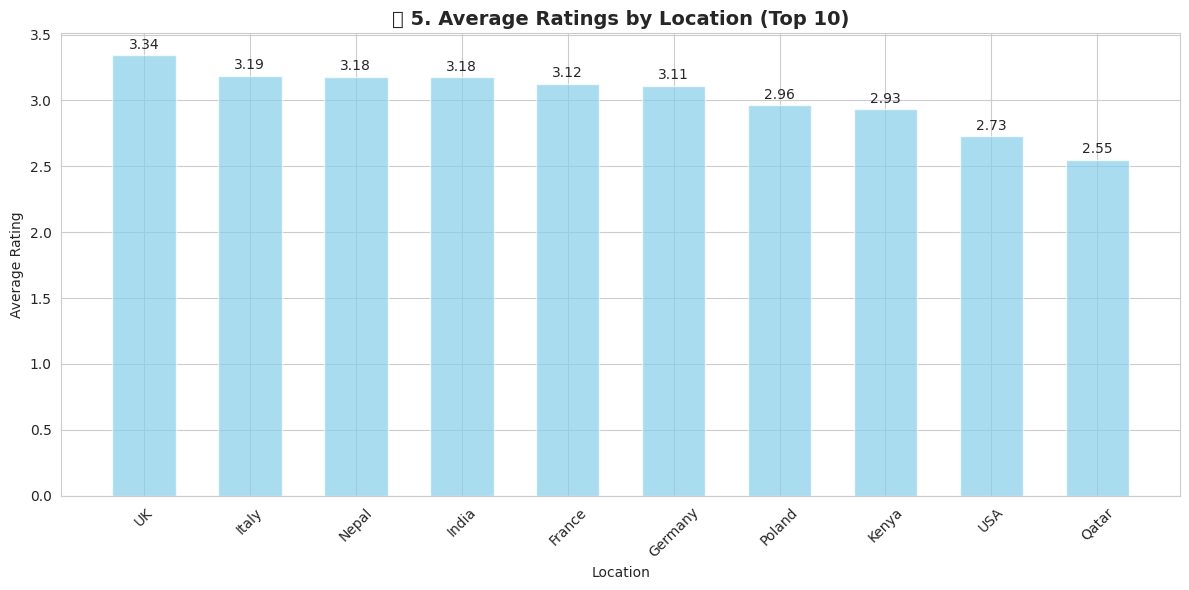

In [26]:
#5
location_ratings = df.groupby('location')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_locations = location_ratings.head(10)
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_locations)), top_locations['mean'],
               color='skyblue', alpha=0.7, width=0.6)
plt.title('🌍 5. Average Ratings by Location (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.xticks(range(len(top_locations)), top_locations.index, rotation=45)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{top_locations["mean"].iloc[i]:.2f}', ha='center')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1588031832.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_stats = df.groupby('platform')['rating'].agg(['mean', 'count']).round(2)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


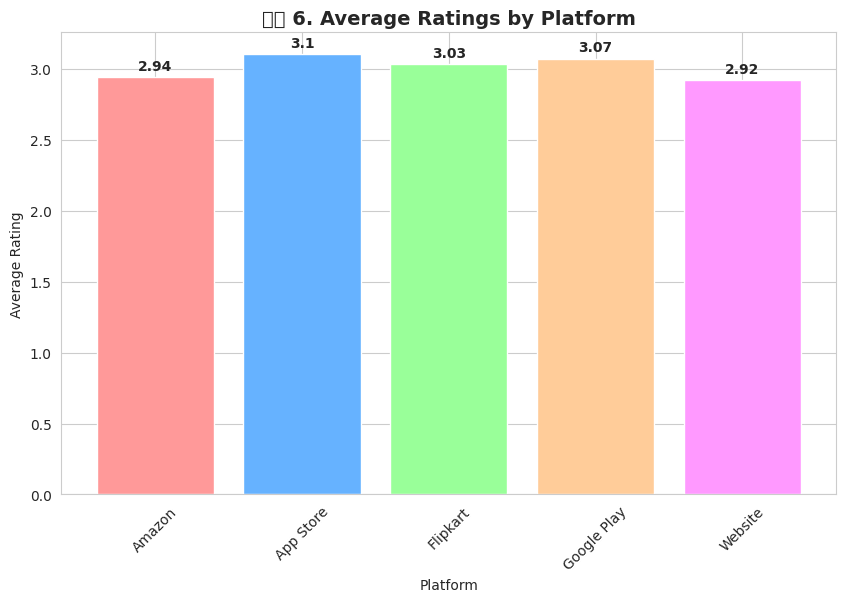

Best platform: App Store


In [27]:
#6
platform_stats = df.groupby('platform')['rating'].agg(['mean', 'count']).round(2)
plt.figure(figsize=(10, 6))
x = range(len(platform_stats))
plt.bar(x, platform_stats['mean'], color=['#FF9999','#66B2FF','#99FF99','#FFCC99','#FF99FF'])
plt.title('🧑‍💻 6. Average Ratings by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Platform')
plt.ylabel('Average Rating')
plt.xticks(x, platform_stats.index, rotation=45)
for i, v in enumerate(platform_stats['mean']):
    plt.text(i, v + 0.05, f'{v}', ha='center', fontweight='bold')
plt.show()
print("Best platform:", platform_stats['mean'].idxmax())

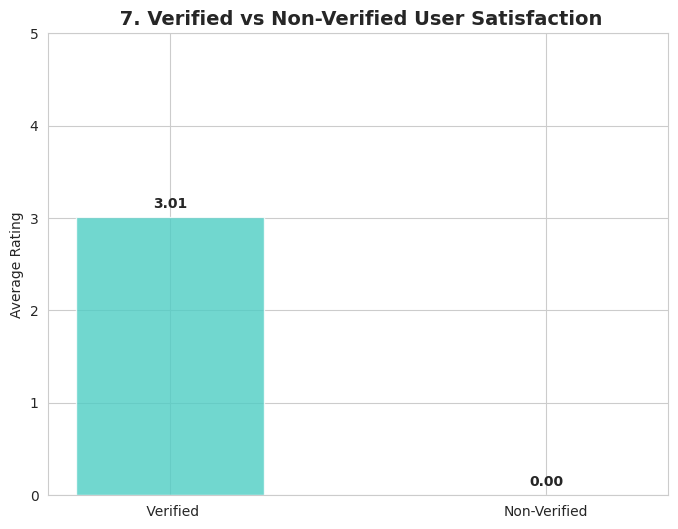

Insight: Verified users happier


In [28]:
#7
verified_avg = df[df['verified_purchase'] == True]['rating'].mean()
non_verified_avg = df[df['verified_purchase'] == False]['rating'].mean() if (df['verified_purchase'] == False).sum() > 0 else 0
plt.figure(figsize=(8, 6))
plt.bar([' Verified', 'Non-Verified'], [verified_avg, non_verified_avg],
        color=['#4ECDC4', '#FF6B6B'], alpha=0.8, width=0.5)
plt.title(' 7. Verified vs Non-Verified User Satisfaction', fontsize=14, fontweight='bold')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
for i, v in enumerate([verified_avg, non_verified_avg]):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()
print(f"Insight: Verified users {'happier' if verified_avg > non_verified_avg else 'similar/less satisfied'}")

<Figure size 1000x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128288 (\N{INPUT SYMBOL FOR LATIN CAPITAL LETTERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


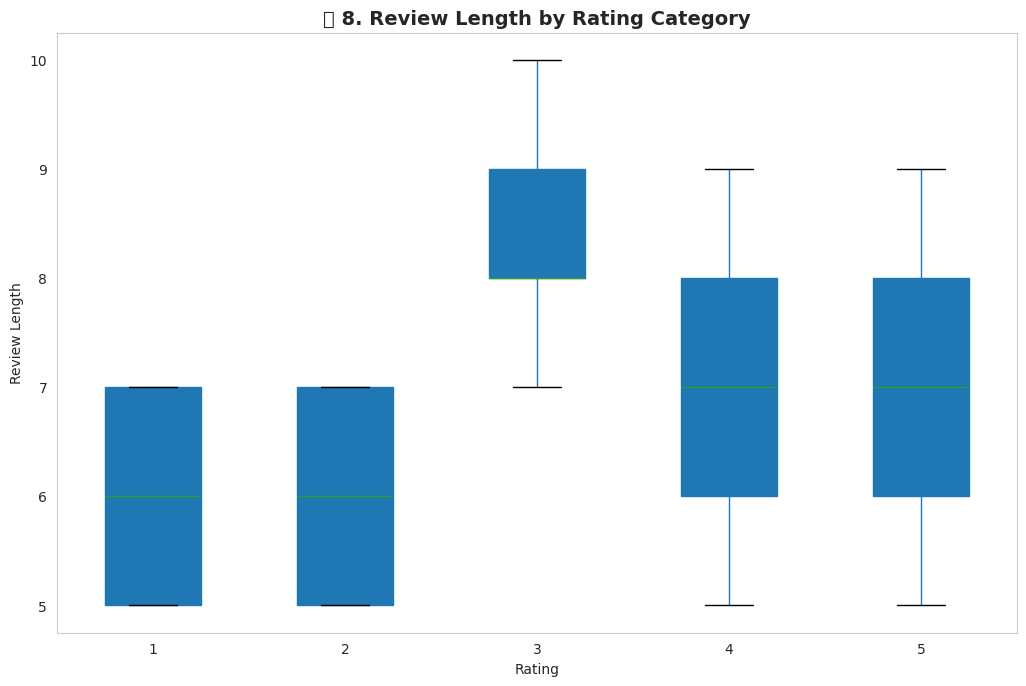

Insight: Length consistent across ratings


In [29]:
#8
plt.figure(figsize=(10, 6))
df.boxplot(column='review_length', by='rating', grid=False, patch_artist=True)
plt.title('🔠 8. Review Length by Rating Category', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Review Length')
plt.suptitle('')
plt.show()
print("Insight:", "Unhappy users write longer reviews" if df.groupby('rating')['review_length'].mean().iloc[0] > df.groupby('rating')['review_length'].mean().iloc[-1] else "Length consistent across ratings")

/tmp/ipython-input-2115362347.py:15: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


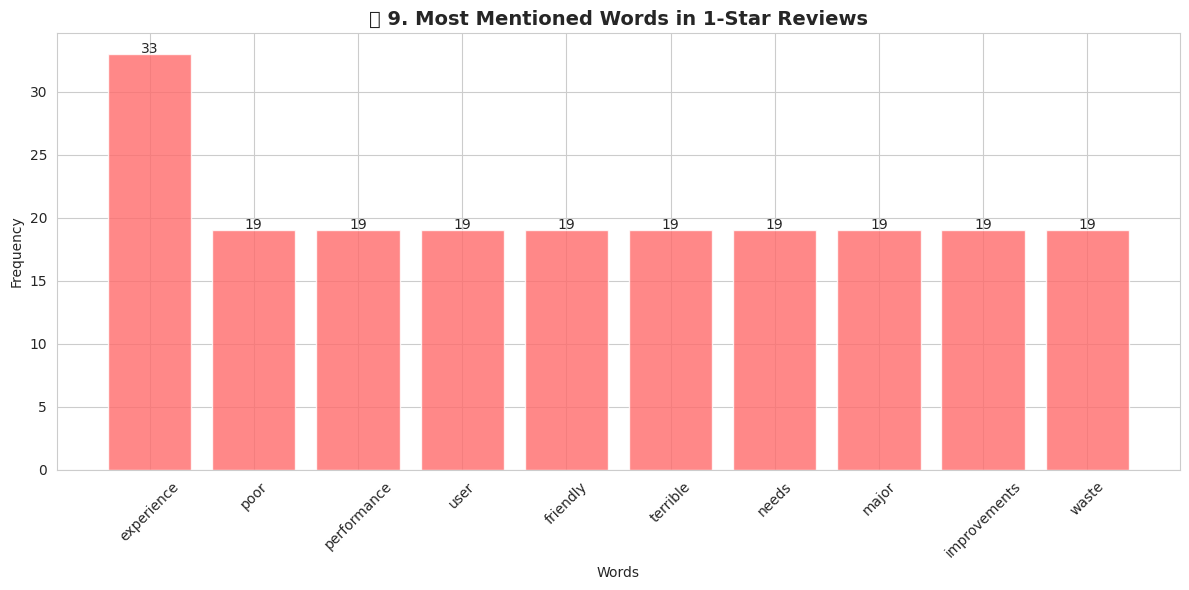

Top complaints: experience, poor, performance


In [30]:
#9

one_star_reviews = df[df['rating'] == 1]['review'].fillna('').apply(clean_words)
all_words = ' '.join(one_star_reviews).split()
word_freq = Counter(all_words).most_common(10)
plt.figure(figsize=(12, 6))
words, counts = zip(*word_freq)
plt.bar(words, counts, color='#FF6B6B', alpha=0.8)
plt.title('💬 9. Most Mentioned Words in 1-Star Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
for i, v in enumerate(counts):
    plt.text(i, v + 0.1, str(v), ha='center')
plt.tight_layout()
plt.show()
print("Top complaints:", ', '.join([w[0] for w in word_freq[:3]]))


/tmp/ipython-input-2921333461.py:13: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2921333461.py:13: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


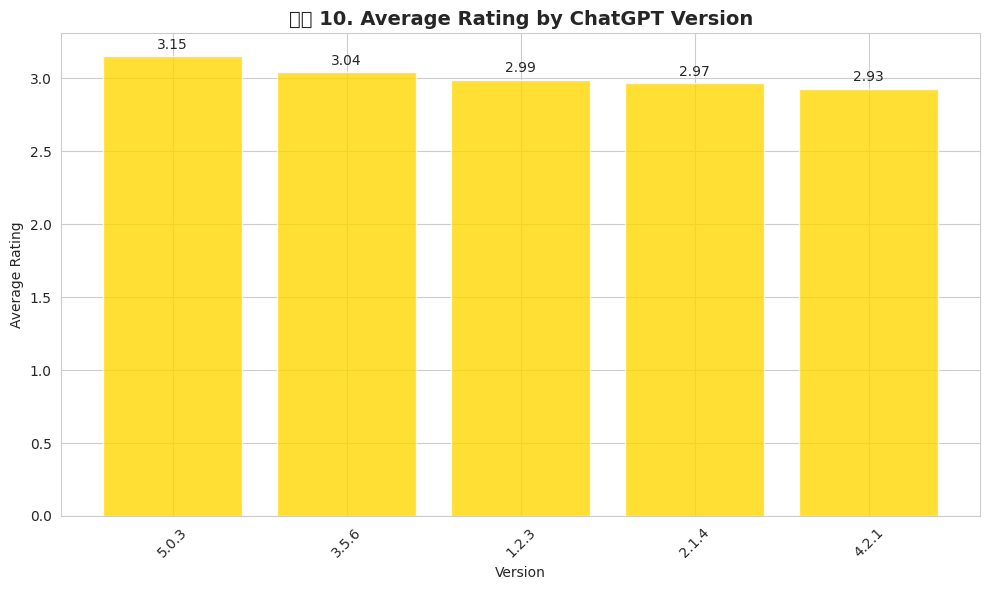

Highest rated version: 5.0.3


In [31]:
#10

version_ratings = df.groupby('version')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(version_ratings)), version_ratings['mean'], color='gold', alpha=0.8)
plt.title('📱🧪 10. Average Rating by ChatGPT Version', fontsize=14, fontweight='bold')
plt.xlabel('Version')
plt.ylabel('Average Rating')
plt.xticks(range(len(version_ratings)), version_ratings.index, rotation=45)
for i, bar in enumerate(bars):
    height = version_ratings['mean'].iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.2f}', ha='center')
plt.tight_layout()
plt.show()
print("Highest rated version:", version_ratings['mean'].idxmax())


In [32]:
from sklearn.model_selection import train_test_split

# Re-split using same random state
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

# Encode AFTER split (best practice)
X_train_bert = bert_model.encode(
    X_train_text.tolist(),
    show_progress_bar=True
)

X_test_bert = bert_model.encode(
    X_test_text.tolist(),
    show_progress_bar=True)


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_bert,
    y_train
)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


def get_models():

    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

        "Neural Net (LSTM-like)": MLPClassifier(
            hidden_layer_sizes=(256,128),
            max_iter=500
        )
    }


In [35]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize


def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    y_test_bin = label_binarize(
        y_test,
        classes=[0,1,2]
    )

    auc = roc_auc_score(
        y_test_bin,
        y_proba,
        multi_class="ovr"
    )

    print(f"AUC-ROC: {auc:.4f}")


In [36]:
def train_bert_models(X_train, X_test, y_train, y_test):

    models = get_models()

    for name, model in models.items():

        print(f"\nTraining {name}...")

        model.fit(X_train, y_train)

        evaluate_model(
            name,
            model,
            X_test,
            y_test
        )


In [37]:
train_bert_models(
    X_train_bal,
    X_test_bert,
    y_train_bal,
    y_test
)



Training Logistic Regression...

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC-ROC: 1.0000

Training Random Forest...

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC-ROC: 1.0000

Training Neural Net (LSTM-like)...

===== Neural Net (LSTM-like) =====
              

In [38]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def plot_multiclass_roc(model, X_test, y_test, model_name):

    # Binarize labels (0,1,2)
    y_test_bin = label_binarize(y_test, classes=[0,1,2])
    n_classes = y_test_bin.shape[1]

    # Get probabilities
    y_score = model.predict_proba(X_test)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot
    plt.figure(figsize=(8,6))

    for i in range(n_classes):
        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"Class {i} (AUC = {roc_auc[i]:.2f})"
        )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        linestyle="--",
        color="black",
        label=f"Macro Avg (AUC = {roc_auc['macro']:.2f})"
    )

    plt.plot([0,1], [0,1], linestyle=":", color="gray")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


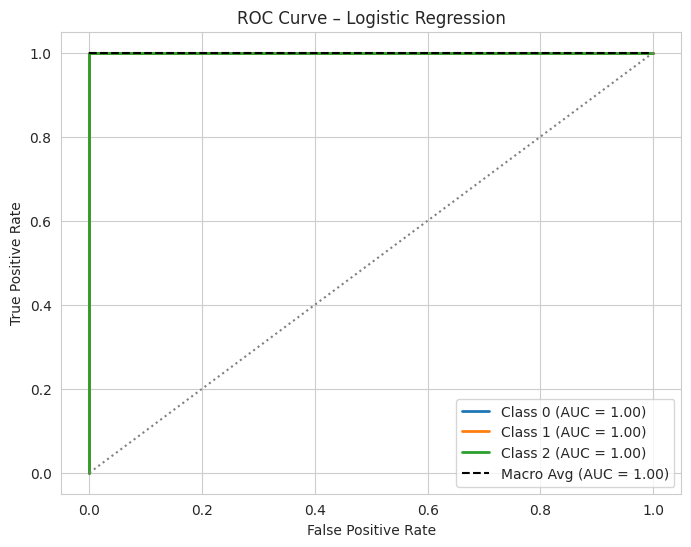

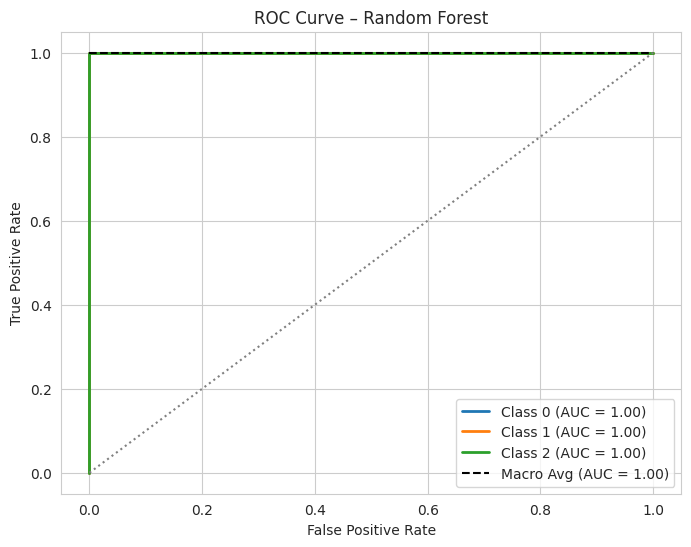

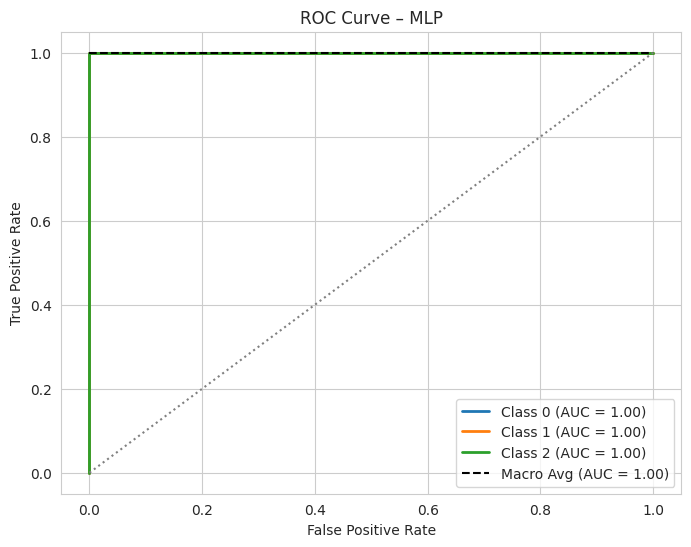

In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), max_iter=500)
}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    plot_multiclass_roc(model, X_test_bert, y_test, name)


In [40]:
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


def prepare_lstm_data(
    X_train,
    X_test,
    y_train,
    y_test,
    max_words=10000,
    max_len=120
):

    # Ensure text
    X_train = X_train.astype(str)
    X_test = X_test.astype(str)

    # Tokenizer
    tokenizer = Tokenizer(
        num_words=max_words,
        oov_token="<OOV>"
    )

    tokenizer.fit_on_texts(X_train)

    # Text → Sequences
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)

    # Padding
    X_train_pad = pad_sequences(
        X_train_seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    X_test_pad = pad_sequences(
        X_test_seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    # Labels → One-hot
    y_train_cat = to_categorical(y_train, num_classes=3)
    y_test_cat = to_categorical(y_test, num_classes=3)

    return X_train_pad, X_test_pad, y_train_cat, y_test_cat, tokenizer


In [41]:
from sklearn.utils.class_weight import compute_class_weight


def get_class_weights(y_train):

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    return dict(zip(classes, weights))


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Input
)


def build_lstm_model(
    vocab_size,
    embedding_dim,
    max_len
):

    model = Sequential([

        # Input (IMPORTANT)
        Input(shape=(max_len,)),

        # Embedding
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ),

        # Smaller BiLSTM
        Bidirectional(
            LSTM(32)
        ),

        Dropout(0.4),

        Dense(32, activation="relu"),

        Dropout(0.2),

        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [43]:
from tensorflow.keras.callbacks import EarlyStopping


def train_lstm_model(
    model,
    X_train_pad,
    y_train_cat,
    class_weights,
    epochs=25,
    batch_size=16
):

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train_cat,

        validation_split=0.15,

        epochs=epochs,
        batch_size=batch_size,

        class_weight=class_weights,

        callbacks=[early_stop],

        verbose=1
    )

    return history


In [44]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize


def evaluate_lstm_model(
    model,
    X_test_pad,
    y_test
):

    # Probabilities
    y_proba = model.predict(X_test_pad)

    # Classes
    y_pred = np.argmax(y_proba, axis=1)

    print("\n===== LSTM PERFORMANCE =====\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Negative","Neutral","Positive"]
        )
    )

    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")

    # AUC
    y_test_bin = label_binarize(
        y_test,
        classes=[0,1,2]
    )

    auc = roc_auc_score(
        y_test_bin,
        y_proba,
        multi_class="ovr"
    )

    print(f"AUC-ROC: {auc:.4f}")

    # Prediction distribution
    print("\nPrediction Distribution:")
    print(np.bincount(y_pred))


In [45]:
def predict_reviews_lstm(
    texts,
    model,
    tokenizer,
    max_len
):

    texts = [str(t).lower() for t in texts]

    seq = tokenizer.texts_to_sequences(texts)

    pad = pad_sequences(
        seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    probs = model.predict(pad)

    preds = np.argmax(probs, axis=1)

    labels = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }

    results = []

    for i in range(len(texts)):

        results.append({
            "Review": texts[i],
            "Prediction": labels[preds[i]],
            "Confidence": round(float(np.max(probs[i])), 3)
        })

    return results


In [46]:
X_train_pad, X_test_pad, y_train_cat, y_test_cat, tokenizer = prepare_lstm_data(
    X_train_text,
    X_test_text,
    y_train,
    y_test
)


In [47]:
vocab_size = min(
    10000,
    len(tokenizer.word_index) + 1
)

max_len = X_train_pad.shape[1]


In [48]:
class_weights = get_class_weights(y_train)

print("Class Weights:", class_weights)


Class Weights: {np.int64(0): np.float64(0.8547008547008547), np.int64(1): np.float64(1.5873015873015872), np.int64(2): np.float64(0.8333333333333334)}


In [49]:
lstm_model = build_lstm_model(
    vocab_size=vocab_size,
    embedding_dim=100,
    max_len=max_len
)

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 100)       │         7,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,927 (171.59 KB)

 Trainable params: 43,927 (171.59 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = train_lstm_model(
    lstm_model,
    X_train_pad,
    y_train_cat,
    class_weights
)


Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.3627 - loss: 1.0494 - val_accuracy: 0.6333 - val_loss: 0.9929
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6248 - loss: 0.9509 - val_accuracy: 0.7833 - val_loss: 0.5959
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.8779 - loss: 0.5715 - val_accuracy: 1.0000 - val_loss: 0.1751
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9972 - loss: 0.1945 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9987 - loss: 0.0454 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 232ms/step - accuracy: 1.0000 - loss: 0.0227 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.9948 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 8.2945e-04
Epoch 8/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 1

In [51]:
evaluate_lstm_model(
    lstm_model,
    X_test_pad,
    y_test
)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step

===== LSTM PERFORMANCE =====

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Accuracy: 1.0000
AUC-ROC: 1.0000

Prediction Distribution:
[39 21 40]


In [52]:
samples = [
    "This product is amazing and works perfectly",
    "It's okay, nothing special",
    "Worst experience ever. Waste of money",
    "Decent quality for the price",
    "Terrible service and bad product"
]

results = predict_reviews_lstm(
    samples,
    lstm_model,
    tokenizer,
    max_len
)

for r in results:
    print("\n", r)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

 {'Review': 'this product is amazing and works perfectly', 'Prediction': 'Positive', 'Confidence': 1.0}

 {'Review': "it's okay, nothing special", 'Prediction': 'Negative', 'Confidence': 0.905}

 {'Review': 'worst experience ever. waste of money', 'Prediction': 'Negative', 'Confidence': 1.0}

 {'Review': 'decent quality for the price', 'Prediction': 'Positive', 'Confidence': 0.995}

 {'Review': 'terrible service and bad product', 'Prediction': 'Negative', 'Confidence': 0.857}


In [53]:
lstm_model.save("lstm_sentiment_model.keras")


In [54]:
!ls


'chatgpt_style_reviews_dataset (1).xlsx'   sample_data
 lstm_sentiment_model.keras


In [55]:
import tensorflow as tf

model = tf.keras.models.load_model("lstm_sentiment_model.keras")

In [56]:
!ls


'chatgpt_style_reviews_dataset (1).xlsx'   sample_data
 lstm_sentiment_model.keras


In [57]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [58]:
samples = [
    "This product is amazing and works perfectly",
    "It's okay, nothing special",
    "Worst experience ever. Waste of money",
    "Decent quality for the price",
    "Terrible service and bad product"
]

results = predict_reviews_lstm(
    samples,
    model,
    tokenizer,
    max_len
)

for r in results:
    print("\n", r)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step

 {'Review': 'this product is amazing and works perfectly', 'Prediction': 'Positive', 'Confidence': 1.0}

 {'Review': "it's okay, nothing special", 'Prediction': 'Negative', 'Confidence': 0.905}

 {'Review': 'worst experience ever. waste of money', 'Prediction': 'Negative', 'Confidence': 1.0}

 {'Review': 'decent quality for the price', 'Prediction': 'Positive', 'Confidence': 0.995}

 {'Review': 'terrible service and bad product', 'Prediction': 'Negative', 'Confidence': 0.857}
